# Proyecto Data Science 

## Predicción de atraso de vuelos

Autor del proyecto:  **Guillermo Linco**

### Esta versión incluye
- Carga y limpieza del dataset
- Análisis de nulos
- Feature engineering
- EDA con gráficos
- Modelos: Árbol, Bagging, Random Forest y XGBoost
- Versión con balanceo de clases
- Comparación final de modelos
- Exportación de datasets transformados

> Requiere tener `dataset_SCL_EXCEL.xlsx` en la misma carpeta del notebook.



### Importación de librerías

Se importan las librerías necesarias para el proyecto:
- **numpy / pandas**: manipulación de datos.
- **matplotlib / seaborn**: visualización.
- **scikit-learn**: modelos de ML, métricas, pipelines y preprocesamiento.
- **imblearn**: técnicas de balanceo de clases (oversampling).
- **xgboost**: modelo de gradient boosting (se usa si está instalado).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

from imblearn.over_sampling import RandomOverSampler

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid")
print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


## 1) Carga del dataset

> **Dataset**: registros de vuelos del aeropuerto Santiago (SCL) correspondientes al año 2017.
> Contiene información programada y operada de cada vuelo (fechas, aerolínea, destino, etc.).
> El archivo debe llamarse `dataset_SCL_EXCEL.xlsx` y estar en la misma carpeta que este notebook.

In [2]:
DATA_PATH = Path("dataset_SCL_EXCEL.xlsx")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "No se encontró 'dataset_SCL_EXCEL.xlsx'. "
        "Ubica el archivo en la misma carpeta que este notebook."
    )

datos = pd.read_excel(DATA_PATH)
print(f"Shape original: {datos.shape}")
datos.head()


Shape original: (68206, 21)


,Fecha-I,Vlo-I,Ori-I,Des-I,Emp-I,Fecha-O,PERIODO_OPERACION,Vlo-O,Ori-O,Des-O,Emp-O,DIA,MES,AÑO,DIANOM,TIPOVUELO,OPERA,SIGLAORI,SIGLADES,CANTIDAD_PASAJEROS_DESTINO,TIEMPO_VUELO_DESTINO
0,2017-01-01 09:05:00,166,SCEL,SCFA,LAN,2017-01-01 09:15:00,2017-01-01 09:15:00,166,SCEL,SCFA,LAN,1,1,2017,Domingo,N,Grupo LATAM,Santiago,Antofagasta,171,1.530
1,2017-01-01 10:10:00,142,SCEL,SCFA,SKU,2017-01-01 10:10:00,2017-01-01 10:10:00,142,SCEL,SCFA,SKU,1,1,2017,Domingo,N,Sky Airline,Santiago,Antofagasta,104,1.510
2,2017-01-01 14:10:00,150,SCEL,SCFA,SKU,2017-01-01 14:08:00,2017-01-01 14:08:00,150,SCEL,SCFA,SKU,1,1,2017,Domingo,N,Sky Airline,Santiago,Antofagasta,67,1.560
3,2017-01-01 14:10:00,334,SCEL,SCFA,LAN,2017-01-01 14:08:00,2017-01-01 14:08:00,334,SCEL,SCFA,LXP,1,1,2017,Domingo,N,Grupo LATAM,Santiago,Antofagasta,128,1.520
4,2017-01-01 14:20:00,126,SCEL,SCFA,LAN,2017-01-01 14:25:00,2017-01-01 14:25:00,126,SCEL,SCFA,LAN,1,1,2017,Domingo,N,Grupo LATAM,Santiago,Antofagasta,150,1.520


**Limpieza de nombres de columnas**

Los nombres originales del Excel tienen tildes, espacios y guiones que dificultan el acceso desde Python. La función `clean_column_name` los normaliza a minúsculas y sin caracteres especiales.

In [3]:
def clean_column_name(col):
    col = str(col).strip().lower()
    replacements = {
        "á": "a", "é": "e", "í": "i", "ó": "o", "ú": "u",
        "ñ": "n", " ": "_", "-": "_", "/": "_"
    }
    for old, new in replacements.items():
        col = col.replace(old, new)
    return col

datos.columns = [clean_column_name(c) for c in datos.columns]
datos.columns.tolist()


['fecha_i',
 'vlo_i',
 'ori_i',
 'des_i',
 'emp_i',
 'fecha_o',
 'periodo_operacion',
 'vlo_o',
 'ori_o',
 'des_o',
 'emp_o',
 'dia',
 'mes',
 'ano',
 'dianom',
 'tipovuelo',
 'opera',
 'siglaori',
 'siglades',
 'cantidad_pasajeros_destino',
 'tiempo_vuelo_destino']

**Renombrado semántico de columnas**

Se asignan nombres descriptivos en mayúsculas para facilitar la lectura del código. También se convierten las columnas de fecha a tipo `datetime` para poder operar con ellas.

In [4]:
rename_map = {
    "fecha_i": "FECHA_PROGRAMADA",
    "vlo_i": "NUM_VUELO_PROG",
    "ori_i": "COD_CIUDAD_ORIGEN_PROG",
    "des_i": "COD_CIUDAD_DESTINO_PROG",
    "emp_i": "COD_AEROLINEA_PROG",
    "fecha_o": "FECHA_OPERACION",
    "vlo_o": "NUM_VUELO_OPER",
    "ori_o": "COD_CIUDAD_ORIGEN_OPER",
    "des_o": "COD_CIUDAD_DESTINO_OPER",
    "emp_o": "COD_AEROLINEA_OPER",
    "dia": "DIA_OPER",
    "mes": "MES_OPER",
    "ano": "ANIO_OPER",
    "año": "ANIO_OPER",
    "dianom": "DIA_NOM",
    "tipovuelo": "TIPO_VUELO",
    "opera": "OPERA",
    "siglaori": "CIUDAD_ORIGEN",
    "siglades": "CIUDAD_DESTINO",
    "cantidad_pasajeros_destino": "CANTIDAD_PASAJEROS_DESTINO",
    "tiempo_vuelo_destino": "TIEMPO_VUELO_DESTINO",
}

datos = datos.rename(columns=rename_map)

for col in ["FECHA_PROGRAMADA", "FECHA_OPERACION"]:
    datos[col] = pd.to_datetime(datos[col], errors="coerce")

datos.head()


,FECHA_PROGRAMADA,NUM_VUELO_PROG,COD_CIUDAD_ORIGEN_PROG,COD_CIUDAD_DESTINO_PROG,COD_AEROLINEA_PROG,FECHA_OPERACION,periodo_operacion,NUM_VUELO_OPER,COD_CIUDAD_ORIGEN_OPER,COD_CIUDAD_DESTINO_OPER,COD_AEROLINEA_OPER,DIA_OPER,MES_OPER,ANIO_OPER,DIA_NOM,TIPO_VUELO,OPERA,CIUDAD_ORIGEN,CIUDAD_DESTINO,CANTIDAD_PASAJEROS_DESTINO,TIEMPO_VUELO_DESTINO
0,2017-01-01 09:05:00,166,SCEL,SCFA,LAN,2017-01-01 09:15:00,2017-01-01 09:15:00,166,SCEL,SCFA,LAN,1,1,2017,Domingo,N,Grupo LATAM,Santiago,Antofagasta,171,1.530
1,2017-01-01 10:10:00,142,SCEL,SCFA,SKU,2017-01-01 10:10:00,2017-01-01 10:10:00,142,SCEL,SCFA,SKU,1,1,2017,Domingo,N,Sky Airline,Santiago,Antofagasta,104,1.510
2,2017-01-01 14:10:00,150,SCEL,SCFA,SKU,2017-01-01 14:08:00,2017-01-01 14:08:00,150,SCEL,SCFA,SKU,1,1,2017,Domingo,N,Sky Airline,Santiago,Antofagasta,67,1.560
3,2017-01-01 14:10:00,334,SCEL,SCFA,LAN,2017-01-01 14:08:00,2017-01-01 14:08:00,334,SCEL,SCFA,LXP,1,1,2017,Domingo,N,Grupo LATAM,Santiago,Antofagasta,128,1.520
4,2017-01-01 14:20:00,126,SCEL,SCFA,LAN,2017-01-01 14:25:00,2017-01-01 14:25:00,126,SCEL,SCFA,LAN,1,1,2017,Domingo,N,Grupo LATAM,Santiago,Antofagasta,150,1.520


## 2) Revisión de nulos

Se revisa cuántos valores nulos tiene cada columna y qué porcentaje representan. Esto es clave antes de cualquier transformación, ya que los nulos pueden sesgar el modelo.

In [5]:
print("Dimensiones:", datos.shape)
display(datos.dtypes.to_frame("dtype"))

na_table = pd.DataFrame({
    "nulos": datos.isna().sum(),
    "%_nulos": (datos.isna().mean() * 100).round(4)
}).sort_values(["nulos", "%_nulos"], ascending=False)

display(na_table[na_table["nulos"] > 0])

print("Nulos en NUM_VUELO_OPER:", datos["NUM_VUELO_OPER"].isna().sum())
print("Nulos en NUM_VUELO_PROG:", datos["NUM_VUELO_PROG"].isna().sum())


Dimensiones: (68206, 21)


,dtype
FECHA_PROGRAMADA,datetime64[ns]
NUM_VUELO_PROG,object
COD_CIUDAD_ORIGEN_PROG,object
COD_CIUDAD_DESTINO_PROG,object
COD_AEROLINEA_PROG,object
FECHA_OPERACION,datetime64[ns]
periodo_operacion,datetime64[ns]
NUM_VUELO_OPER,object
COD_CIUDAD_ORIGEN_OPER,object
COD_CIUDAD_DESTINO_OPER,object


,nulos,%_nulos
NUM_VUELO_OPER,1,0.002


Nulos en NUM_VUELO_OPER: 1
Nulos en NUM_VUELO_PROG: 0


Solo se encontró **1 registro con valor nulo** (en `NUM_VUELO_OPER`). Se elimina esa fila ya que su impacto es despreciable sobre 68.206 registros totales.

In [6]:
datos2 = datos.dropna().copy()

print("Shape original :", datos.shape)
print("Shape sin nulos:", datos2.shape)
print("Registros eliminados:", len(datos) - len(datos2))


Shape original : (68206, 21)
Shape sin nulos: (68205, 21)
Registros eliminados: 1


## 3) Feature engineering

### Creación de nuevas variables (Feature Engineering)

Se generan variables derivadas que enriquecen la información disponible para los modelos:

| Variable | Descripción |
|---|---|
| `DIFERENCIA_MINUTOS` | Minutos entre la hora operada y la programada (puede ser negativa si salió antes) |
| `ATRASO_15` | Variable objetivo: `'Atrasado'` si la diferencia > 15 min, `'A tiempo'` en caso contrario |
| `TEMPORADA_ALTA` | Indica si el vuelo opera en períodos de alta demanda (verano, fiestas patrias, etc.) |
| `PERIODO_DIA` | Clasifica el horario en Mañana (5-12h), Tarde (12-19h) o Noche |

In [7]:
datos2["DIFERENCIA_MINUTOS"] = (
    (datos2["FECHA_OPERACION"] - datos2["FECHA_PROGRAMADA"]).dt.total_seconds() / 60
)

datos2["ATRASO_15"] = np.where(
    datos2["DIFERENCIA_MINUTOS"] > 15,
    "Atrasado",
    "A tiempo"
)

def temporada_alta(fecha):
    if pd.isna(fecha):
        return "Temporada baja"
    if pd.Timestamp("2016-12-15 00:00:00") <= fecha <= pd.Timestamp("2017-03-03 23:59:59"):
        return "Temporada alta"
    if pd.Timestamp("2017-07-15 00:00:00") <= fecha <= pd.Timestamp("2017-07-31 23:59:59"):
        return "Temporada alta"
    if pd.Timestamp("2017-09-11 00:00:00") <= fecha <= pd.Timestamp("2017-09-30 23:59:59"):
        return "Temporada alta"
    return "Temporada baja"

def periodo_dia(fecha):
    if pd.isna(fecha):
        return "Noche"
    h = fecha.hour + fecha.minute/60
    if 5 <= h < 12:
        return "Mañana"
    elif 12 <= h < 19:
        return "Tarde"
    return "Noche"

datos2["TEMPORADA_ALTA"] = datos2["FECHA_PROGRAMADA"].apply(temporada_alta)
datos2["PERIODO_DIA"] = datos2["FECHA_PROGRAMADA"].apply(periodo_dia)

datos2["TIPO_VUELO"] = datos2["TIPO_VUELO"].replace({
    "N": "Nacional",
    "I": "Internacional"
}).fillna("No definido")

datos2["HORA"] = datos2["FECHA_OPERACION"].dt.hour.astype("Int64")


**Selección de features para el modelado**

Se construye `datos3` con las columnas relevantes para el modelo, descartando variables que son redundantes o que causarían *data leakage* (ej. `FECHA_OPERACION` ya está capturada en `HORA` y `PERIODO_DIA`).

Las columnas categóricas se convierten a tipo `category` para ahorrar memoria y permitir un procesamiento más eficiente.

In [8]:
datos3 = datos2[
    [
        "DIA_OPER", "MES_OPER", "DIA_NOM", "HORA", "TIPO_VUELO",
        "OPERA", "CIUDAD_DESTINO", "ATRASO_15", "TEMPORADA_ALTA",
        "PERIODO_DIA", "CANTIDAD_PASAJEROS_DESTINO", "TIEMPO_VUELO_DESTINO"
    ]
].copy()

categorical_cols = [
    "DIA_OPER", "MES_OPER", "DIA_NOM", "HORA", "TIPO_VUELO",
    "OPERA", "CIUDAD_DESTINO", "TEMPORADA_ALTA", "PERIODO_DIA"
]

for c in categorical_cols:
    datos3[c] = datos3[c].astype("category")

print("Shape de datos3:", datos3.shape)
display(datos3.head())
display(datos3.dtypes.to_frame("dtype"))


Shape de datos3: (68205, 12)


,DIA_OPER,MES_OPER,DIA_NOM,HORA,TIPO_VUELO,OPERA,CIUDAD_DESTINO,ATRASO_15,TEMPORADA_ALTA,PERIODO_DIA,CANTIDAD_PASAJEROS_DESTINO,TIEMPO_VUELO_DESTINO
0,1,1,Domingo,9,Nacional,Grupo LATAM,Antofagasta,A tiempo,Temporada alta,Mañana,171,1.530
1,1,1,Domingo,10,Nacional,Sky Airline,Antofagasta,A tiempo,Temporada alta,Mañana,104,1.510
2,1,1,Domingo,14,Nacional,Sky Airline,Antofagasta,A tiempo,Temporada alta,Tarde,67,1.560
3,1,1,Domingo,14,Nacional,Grupo LATAM,Antofagasta,A tiempo,Temporada alta,Tarde,128,1.520
4,1,1,Domingo,14,Nacional,Grupo LATAM,Antofagasta,A tiempo,Temporada alta,Tarde,150,1.520


,dtype
DIA_OPER,category
MES_OPER,category
DIA_NOM,category
HORA,category
TIPO_VUELO,category
OPERA,category
CIUDAD_DESTINO,category
ATRASO_15,object
TEMPORADA_ALTA,category
PERIODO_DIA,category


## 4) EDA

**Gráfico 1 — Distribución de la variable objetivo**

Permite ver si las clases están balanceadas. Un fuerte desbalance puede hacer que el modelo aprenda a predecir siempre la clase mayoritaria.

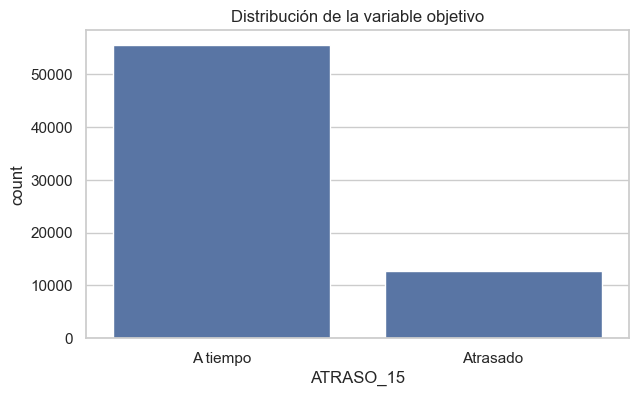

,%
ATRASO_15,
A tiempo,81.510
Atrasado,18.490


In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=datos3, x="ATRASO_15", ax=ax)
ax.set_title("Distribución de la variable objetivo")
plt.show()

display(
    datos3["ATRASO_15"].value_counts(normalize=True).rename("proporcion").mul(100).round(2).to_frame("%")
)


**Gráfico 2 — Distribución de la diferencia en minutos**

Muestra la distribución de la diferencia entre hora operada y programada. La mayoría de los vuelos salen cerca de la hora programada, con una cola larga hacia la derecha (atrasos grandes).

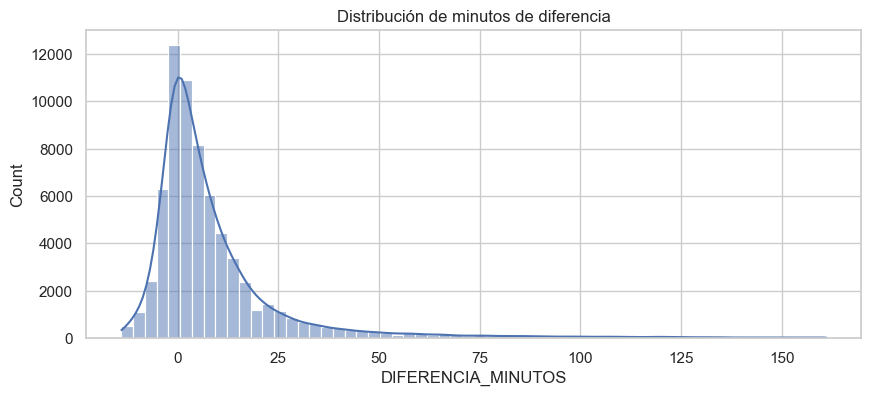

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(data=datos2, x="DIFERENCIA_MINUTOS", bins=60, kde=True, ax=ax)
ax.set_title("Distribución de minutos de diferencia")
plt.show()


**Gráfico 3 — Atraso según período del día**

Explora si la hora de salida influye en la probabilidad de atraso. Es común que los vuelos nocturnos acumulen retrasos por efecto cascada durante el día.

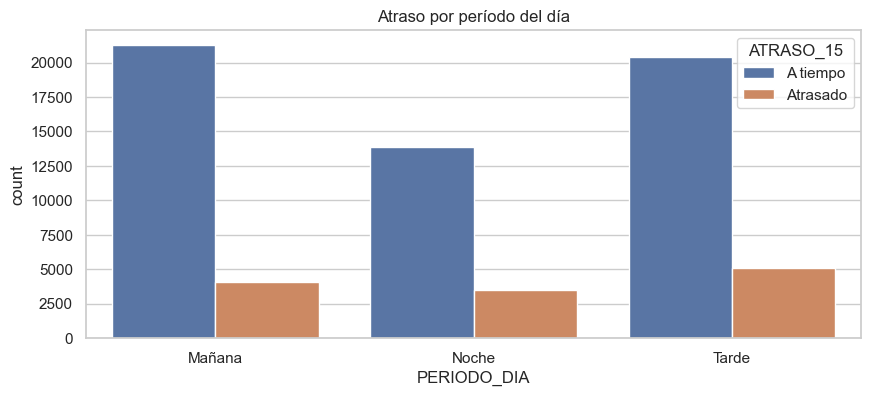

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.countplot(data=datos3, x="PERIODO_DIA", hue="ATRASO_15", ax=ax)
ax.set_title("Atraso por período del día")
plt.show()


### Lectura rápida
- La variable objetivo está desbalanceada.
- El período del día parece influir en el atraso.
- Conviene evaluar tanto modelos base como modelos con balanceo.


## 5) Preparación para modelado

### División en conjuntos de entrenamiento y prueba

- **80% entrenamiento / 20% prueba** con `stratify=y` para mantener la proporción de clases en ambos conjuntos.
- Se construye un **preprocesador** con `ColumnTransformer`:
  - Variables numéricas → imputación por mediana.
  - Variables categóricas → imputación por moda + One-Hot Encoding.
- Se mantiene una versión codificada del target (`y_encoded`) requerida por XGBoost.

In [12]:
X = datos3.drop(columns=["ATRASO_15"]).copy()
y = datos3["ATRASO_15"].copy()

# Codificación numérica SOLO para XGBoost
target_map = {"A tiempo": 0, "Atrasado": 1}
target_map_inv = {v: k for k, v in target_map.items()}
y_encoded = y.map(target_map)

X_train, X_test, y_train, y_test, y_train_encoded, y_test_encoded = train_test_split(
    X, y, y_encoded,
    test_size=0.2,
    stratify=y,
    random_state=2022
)

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)
print("Categóricas:", cat_cols)
print("Numéricas  :", num_cols)
print("Codificación target XGBoost:", target_map)


Train: (54564, 11) (54564,)
Test : (13641, 11) (13641,)
Categóricas: ['DIA_OPER', 'MES_OPER', 'DIA_NOM', 'HORA', 'TIPO_VUELO', 'OPERA', 'CIUDAD_DESTINO', 'TEMPORADA_ALTA', 'PERIODO_DIA']
Numéricas  : ['CANTIDAD_PASAJEROS_DESTINO', 'TIEMPO_VUELO_DESTINO']
Codificación target XGBoost: {'A tiempo': 0, 'Atrasado': 1}


**Función de evaluación de modelos**

`evaluate_model` centraliza el cálculo de métricas para todos los modelos:
- **Accuracy**: proporción de predicciones correctas.
- **ROC AUC**: mide la capacidad discriminativa del modelo (1 = perfecto, 0.5 = aleatorio).
- **Classification report**: precisión, recall y F1 por clase.
- **Matriz de confusión**: visualiza verdaderos/falsos positivos y negativos.

Esta función maneja tanto modelos con target texto (`'A tiempo'`) como numérico (XGBoost).

In [13]:
def get_positive_proba(model, X, positive_label="A tiempo", encoded_positive_value=0):
    proba = model.predict_proba(X)
    classes = list(model.classes_)

    if positive_label in classes:
        pos_idx = classes.index(positive_label)
        return proba[:, pos_idx]

    if encoded_positive_value in classes:
        pos_idx = classes.index(encoded_positive_value)
        return proba[:, pos_idx]

    raise ValueError(
        f"No se encontró la clase positiva '{positive_label}' ni el valor codificado "
        f"{encoded_positive_value} dentro de classes_: {classes}"
    )

def decode_if_needed(values, inverse_map=None):
    values = np.asarray(values)
    if inverse_map is None:
        return values
    return np.array([inverse_map.get(v, v) for v in values])

def evaluate_model(
    name,
    model,
    X_test,
    y_test,
    positive_label="A tiempo",
    encoded_positive_value=0,
    target_inverse_map=None,
    show_cm=True
):
    y_pred = model.predict(X_test)
    y_pred_labels = decode_if_needed(y_pred, target_inverse_map)

    y_proba = get_positive_proba(
        model,
        X_test,
        positive_label=positive_label,
        encoded_positive_value=encoded_positive_value
    )

    y_true_binary = (pd.Series(y_test).astype(str) == positive_label).astype(int)

    acc = accuracy_score(y_test, y_pred_labels)
    auc = roc_auc_score(y_true_binary, y_proba)

    print(f"Modelo: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC AUC : {auc:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred_labels))

    if show_cm:
        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred_labels, ax=ax)
        ax.set_title(f"Matriz de confusión — {name}")
        plt.show()

    return {"modelo": name, "accuracy": acc, "roc_auc": auc}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2022)


## 6) Árbol de decisión tuneado

**¿Por qué un Árbol de Decisión?**

Es el modelo más interpretable: sus reglas pueden explicarse a cualquier audiencia. Se aplica **GridSearchCV** con validación cruzada estratificada (5 folds) para ajustar:
- `max_depth`: profundidad máxima del árbol (controla el overfitting).
- `min_samples_leaf`: mínimo de muestras en hojas terminales.
- `ccp_alpha`: poda basada en costo-complejidad.

Mejores hiperparámetros: {'model__ccp_alpha': 0.0, 'model__max_depth': 8, 'model__min_samples_leaf': 10}
Modelo: Decision Tree
Accuracy: 0.8232
ROC AUC : 0.6596

Classification report:
              precision    recall  f1-score   support

    A tiempo       0.83      0.99      0.90     11118
    Atrasado       0.63      0.11      0.18      2523

    accuracy                           0.82     13641
   macro avg       0.73      0.55      0.54     13641
weighted avg       0.79      0.82      0.77     13641



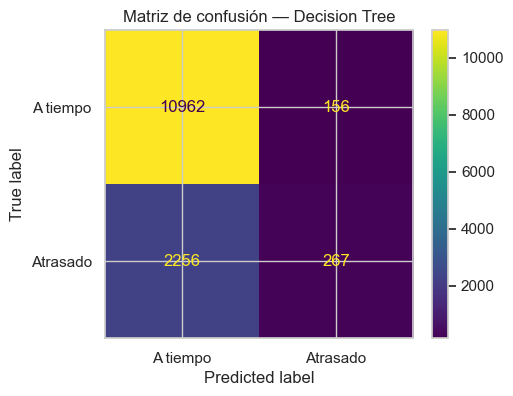

In [14]:
tree_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier(random_state=2022))
])

tree_grid = {
    "model__ccp_alpha": np.linspace(0.0, 0.01, 6),
    "model__max_depth": [3, 4, 5, 6, 7, 8],
    "model__min_samples_leaf": [1, 2, 3, 5, 10]
}

tree_search = GridSearchCV(
    estimator=tree_pipe,
    param_grid=tree_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

tree_search.fit(X_train, y_train)
print("Mejores hiperparámetros:", tree_search.best_params_)

tree_best = tree_search.best_estimator_
results.append(evaluate_model("Decision Tree", tree_best, X_test, y_test))


## 7) Bagging

**¿Por qué Bagging?**

Bagging (Bootstrap Aggregating) entrena múltiples árboles sobre subconjuntos aleatorios del dataset y promedia sus predicciones. Reduce la varianza respecto a un árbol individual sin necesitar búsqueda de hiperparámetros exhaustiva. Se usan 100 estimadores base.

Modelo: Bagging
Accuracy: 0.8406
ROC AUC : 0.7700

Classification report:
              precision    recall  f1-score   support

    A tiempo       0.86      0.97      0.91     11118
    Atrasado       0.66      0.29      0.40      2523

    accuracy                           0.84     13641
   macro avg       0.76      0.63      0.65     13641
weighted avg       0.82      0.84      0.81     13641



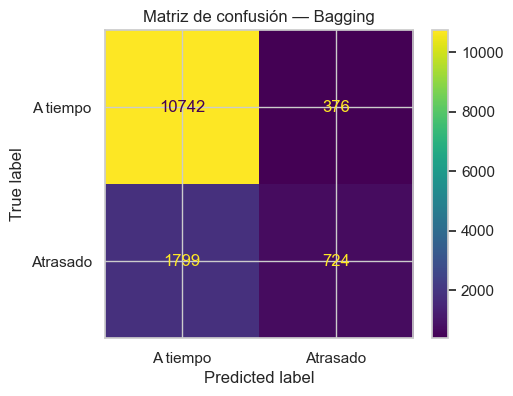

In [15]:
bag_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=2022),
        n_estimators=100,
        random_state=2022,
        n_jobs=-1
    ))
])

bag_pipe.fit(X_train, y_train)
results.append(evaluate_model("Bagging", bag_pipe, X_test, y_test))


## 8) Random Forest tuneado

**¿Por qué Random Forest?**

Es una extensión de Bagging que además selecciona aleatoriamente un subconjunto de features en cada split, lo que decorrelaciona los árboles y mejora la generalización. Se optimiza con GridSearchCV sobre `n_estimators`, `max_depth`, `min_samples_leaf` y `max_features`.

Mejores hiperparámetros: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__n_estimators': 400}
Modelo: Random Forest
Accuracy: 0.8372
ROC AUC : 0.7968

Classification report:
              precision    recall  f1-score   support

    A tiempo       0.84      0.99      0.91     11118
    Atrasado       0.78      0.17      0.27      2523

    accuracy                           0.84     13641
   macro avg       0.81      0.58      0.59     13641
weighted avg       0.83      0.84      0.79     13641



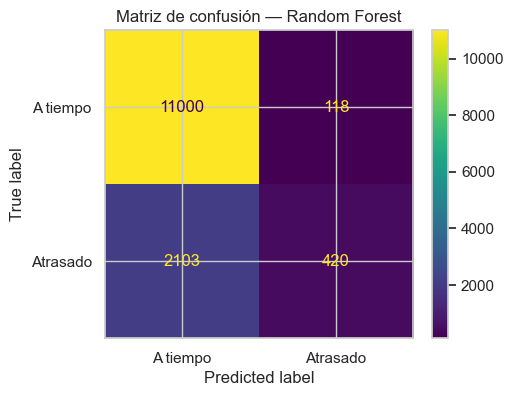

In [16]:
rf_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestClassifier(random_state=2022, n_jobs=-1))
])

rf_grid = {
    "model__n_estimators": [100, 200, 400],
    "model__max_depth": [None, 8, 12],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

rf_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
print("Mejores hiperparámetros:", rf_search.best_params_)

rf_best = rf_search.best_estimator_
results.append(evaluate_model("Random Forest", rf_best, X_test, y_test))


## 9) XGBoost

**¿Por qué XGBoost?**

XGBoost (Extreme Gradient Boosting) construye árboles de forma **secuencial**: cada nuevo árbol corrige los errores del anterior. Suele obtener el mejor rendimiento en datos tabulares. Requiere que el target esté codificado numéricamente (0/1).

> *Nota: si XGBoost no está instalado, esta celda se omite automáticamente.*

Modelo: XGBoost
Accuracy: 0.8357
ROC AUC : 0.7785

Classification report:
              precision    recall  f1-score   support

    A tiempo       0.84      0.99      0.91     11118
    Atrasado       0.77      0.16      0.26      2523

    accuracy                           0.84     13641
   macro avg       0.80      0.57      0.59     13641
weighted avg       0.83      0.84      0.79     13641



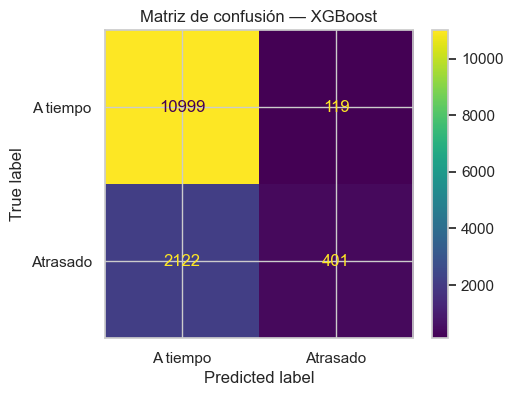

In [17]:
if XGB_AVAILABLE:
    xgb_pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            n_estimators=250,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=2022
        ))
    ])

    # XGBoost requiere target numérico
    xgb_pipe.fit(X_train, y_train_encoded)

    results.append(
        evaluate_model(
            "XGBoost",
            xgb_pipe,
            X_test,
            y_test,
            positive_label="A tiempo",
            encoded_positive_value=0,
            target_inverse_map=target_map_inv
        )
    )
else:
    print("XGBoost no está instalado. Ejecuta: pip install xgboost")


## 10) Balanceo de clases con oversampling

### Balanceo de clases con RandomOverSampler

El dataset está desbalanceado (~81% `A tiempo` vs ~18% `Atrasado`). Con `RandomOverSampler` se **duplican** aleatoriamente registros de la clase minoritaria hasta igualar ambas clases **solo en el set de entrenamiento**.

> ⚠️ El set de prueba **no se modifica**: las métricas deben evaluarse en datos reales.

In [18]:
ros = RandomOverSampler(random_state=2022)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

# Versión codificada del target balanceado para XGBoost
_, y_train_bal_encoded = ros.fit_resample(X_train, y_train_encoded)

print("Distribución original:")
display(y_train.value_counts(normalize=True).mul(100).round(2).to_frame("%"))

print("Distribución balanceada:")
display(y_train_bal.value_counts(normalize=True).mul(100).round(2).to_frame("%"))


Distribución original:


,%
ATRASO_15,
A tiempo,81.510
Atrasado,18.490


Distribución balanceada:


,%
ATRASO_15,
A tiempo,50.000
Atrasado,50.000


**Random Forest entrenado sobre datos balanceados**

Se reutiliza la mejor configuración de Random Forest pero entrenando con los datos balanceados. El objetivo es ver si mejora la detección de la clase minoritaria (`Atrasado`) a costa de posiblemente bajar la accuracy general.

Modelo: Random Forest + Oversampling
Accuracy: 0.8367
ROC AUC : 0.7941

Classification report:
              precision    recall  f1-score   support

    A tiempo       0.86      0.95      0.90     11118
    Atrasado       0.60      0.35      0.44      2523

    accuracy                           0.84     13641
   macro avg       0.73      0.65      0.67     13641
weighted avg       0.82      0.84      0.82     13641



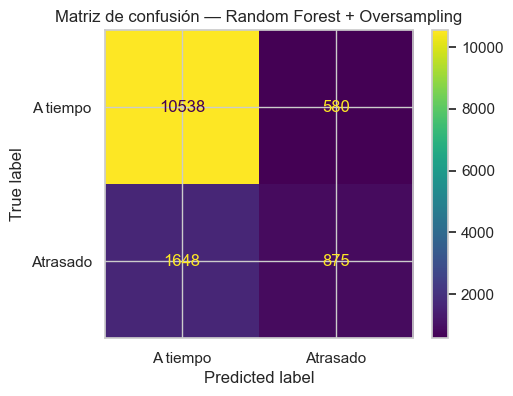

In [19]:
rf_bal_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=1,
        max_features="sqrt",
        random_state=2022,
        n_jobs=-1
    ))
])

rf_bal_pipe.fit(X_train_bal, y_train_bal)
results.append(evaluate_model("Random Forest + Oversampling", rf_bal_pipe, X_test, y_test))


**Árbol de Decisión entrenado sobre datos balanceados**

Mismo árbol tuneado anteriormente, ahora entrenado con datos balanceados para evaluar el impacto del oversampling en un modelo simple e interpretable.

Modelo: Decision Tree + Oversampling
Accuracy: 0.5434
ROC AUC : 0.6367

Classification report:
              precision    recall  f1-score   support

    A tiempo       0.88      0.51      0.64     11118
    Atrasado       0.25      0.71      0.36      2523

    accuracy                           0.54     13641
   macro avg       0.56      0.61      0.50     13641
weighted avg       0.77      0.54      0.59     13641



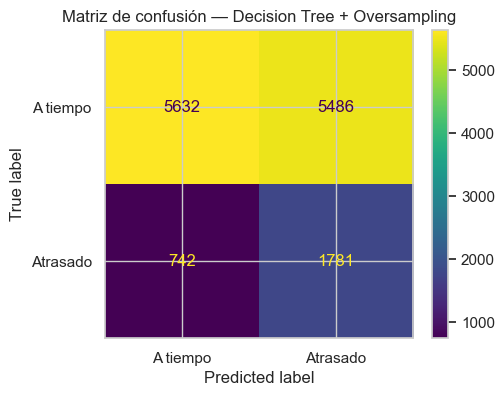

In [20]:
tree_bal_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=3,
        random_state=2022
    ))
])

tree_bal_pipe.fit(X_train_bal, y_train_bal)
results.append(evaluate_model("Decision Tree + Oversampling", tree_bal_pipe, X_test, y_test))


**XGBoost entrenado sobre datos balanceados**

Se aplica la misma configuración de XGBoost usando el dataset balanceado. Permite comparar si el oversampling beneficia al modelo más poderoso.

Modelo: XGBoost + Oversampling
Accuracy: 0.7241
ROC AUC : 0.7780

Classification report:
              precision    recall  f1-score   support

    A tiempo       0.91      0.73      0.81     11118
    Atrasado       0.37      0.69      0.48      2523

    accuracy                           0.72     13641
   macro avg       0.64      0.71      0.65     13641
weighted avg       0.81      0.72      0.75     13641



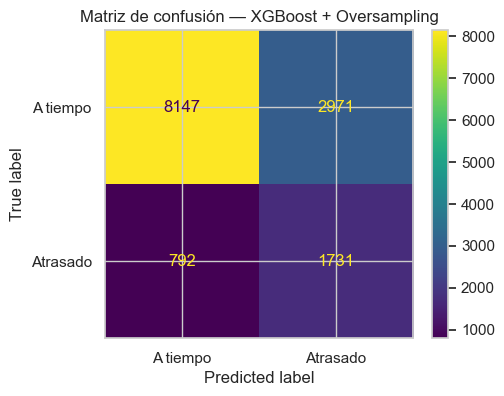

In [21]:
if XGB_AVAILABLE:
    xgb_bal_pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            n_estimators=250,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=2022
        ))
    ])

    xgb_bal_pipe.fit(X_train_bal, y_train_bal_encoded)

    results.append(
        evaluate_model(
            "XGBoost + Oversampling",
            xgb_bal_pipe,
            X_test,
            y_test,
            positive_label="A tiempo",
            encoded_positive_value=0,
            target_inverse_map=target_map_inv
        )
    )
else:
    print("XGBoost no está instalado. Se omite la versión balanceada.")


## 11) Comparación final

### Tabla comparativa de todos los modelos

Se consolidan los resultados de accuracy y ROC AUC para cada modelo, ordenados de mayor a menor ROC AUC. Se genera un gráfico de barras para facilitar la comparación visual entre modelos con y sin balanceo.

,modelo,accuracy,roc_auc
0,Random Forest,0.837,0.797
1,Random Forest + Oversampling,0.837,0.794
2,XGBoost,0.836,0.778
3,XGBoost + Oversampling,0.724,0.778
4,Bagging,0.841,0.770
5,Decision Tree,0.823,0.660
6,Decision Tree + Oversampling,0.543,0.637


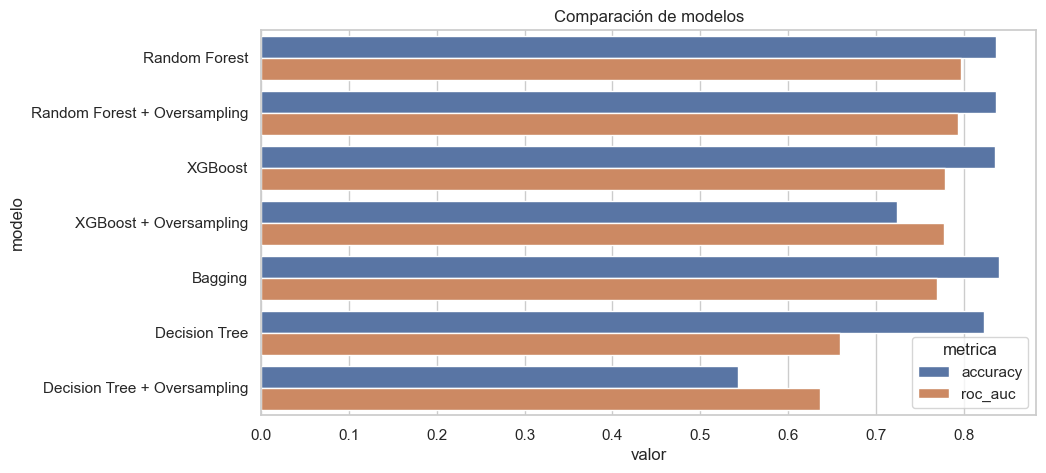

In [22]:
results_df = pd.DataFrame(results).sort_values(
    ["roc_auc", "accuracy"], ascending=False
).reset_index(drop=True)

display(results_df)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = results_df.melt(
    id_vars="modelo",
    value_vars=["accuracy", "roc_auc"],
    var_name="metrica",
    value_name="valor"
)
sns.barplot(data=plot_df, x="valor", y="modelo", hue="metrica", ax=ax)
ax.set_title("Comparación de modelos")
plt.show()


## 12) Conclusiones sugeridas

### Hallazgos
1. El problema tiene clases desbalanceadas.
2. Los árboles son útiles por interpretabilidad.
3. Random Forest y XGBoost suelen entregar mejor performance general.
4. El oversampling puede ayudar a detectar mejor la clase minoritaria.

### Recomendación
- Si buscas **explicación**, usa árbol.
- Si buscas **mejor performance**, prioriza Random Forest o XGBoost.
- Reporta **accuracy, ROC AUC y matriz de confusión**.


## 13) Exportación de datasets transformados

### Exportación de datos transformados

Se exportan dos archivos para uso posterior (análisis adicionales, dashboards, etc.):
- `datos3.csv` → dataset final con las features seleccionadas y la variable objetivo.
- `data_balanceada.csv` → dataset de entrenamiento con clases balanceadas (oversampling aplicado).

In [23]:
datos3.to_csv("datos3.csv", index=False)
balanceado = pd.concat([X_train_bal, y_train_bal], axis=1)
balanceado.to_csv("data_balanceada.csv", index=False)

print("Archivos exportados:")
print("- datos3.csv")
print("- data_balanceada.csv")


Archivos exportados:
- datos3.csv
- data_balanceada.csv
